In [1]:
import json
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D
import numpy as np
import os

...Successfully processed data for β=0.1.
...Successfully processed data for β=1.0.
...Successfully processed data for β=5.0.
...Successfully processed data for β=20.0.
...Successfully processed data for β=50.0.


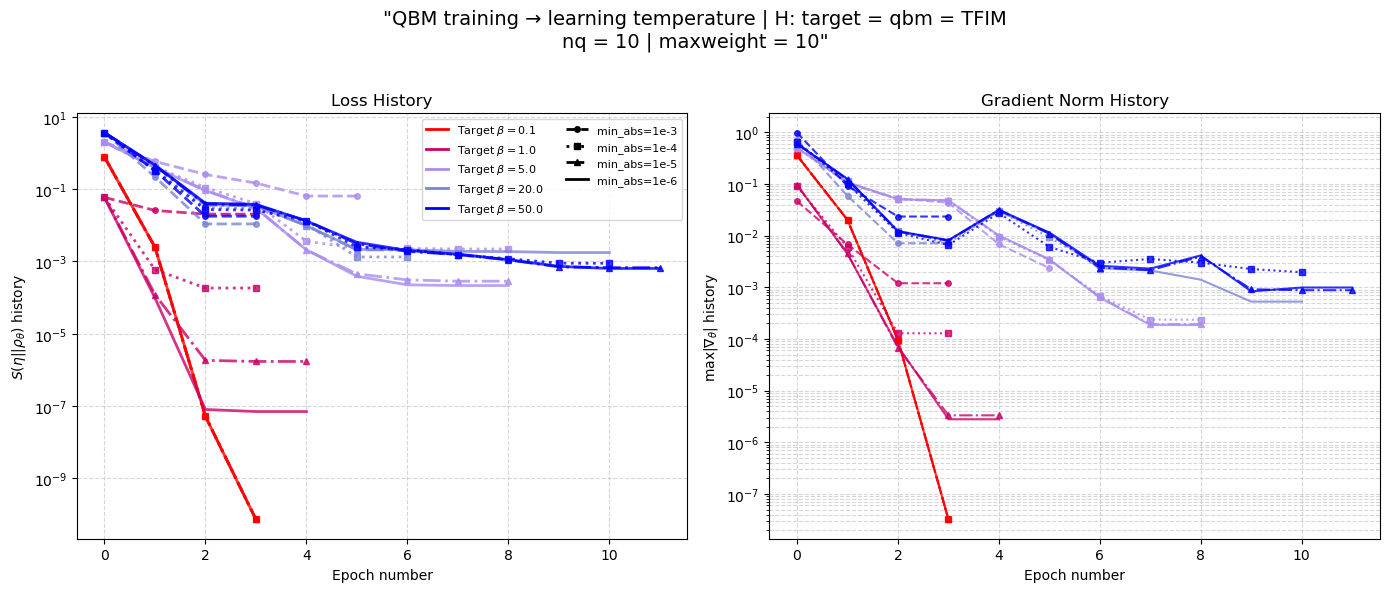

In [5]:
# --- 1. Define File and Style Maps ---

FILE_MAP = {
    0.1: ("qbm_optimization_N10_B0.1_20251203_133817.json", 'red'),
    1.0: ("qbm_optimization_N10_B1_20251203_093021.json", '#CC0066'),  # Reddish-Magenta
    5.0: ("qbm_optimization_N10_B5_20251203_133912.json", '#A98CEE'),  # Soft Purple
    20.0: ("qbm_optimization_N10_B20_20251203_134640.json", '#7C84D4'),  # Periwinkle
    50.0: ("qbm_optimization_N10_B50_20251203_102817.json", 'blue')
}

COEFF_STYLES = {
    1.0e-3: {'linestyle': '--', 'marker': 'o', 'ms': 4, 'lw': 2, 'label': 'min_abs=1e-3'},
    1.0e-4: {'linestyle': ':', 'marker': 's', 'ms': 4, 'lw': 2, 'label': 'min_abs=1e-4'},
    1.0e-5: {'linestyle': '-.', 'marker': '^', 'ms': 4, 'lw': 2, 'label': 'min_abs=1e-5'},
    1.0e-6: {'linestyle': '-', 'marker': 'None', 'ms': 0, 'lw': 2, 'label': 'min_abs=1e-6'}
}

BASE_DIR = "/Users/micheleminervini/Desktop/PauliSampling.jl/numerics/quantumboltzmannmachines/data/learn_temperature"

# Sort keys for consistent plotting order (low beta to high beta)
beta_keys = sorted(FILE_MAP.keys())
all_data = [] # List to store all parsed data

# --- 2. Data Loading Function ---

def load_data():
    """Loads and parses all JSON files."""
    for beta in beta_keys:
        filename_base, beta_color = FILE_MAP[beta]
        filename = os.path.join(BASE_DIR, filename_base)
        
        try:
            with open(filename, 'r') as f:
                # Python's json library is generally robust with numeric arrays
                data = json.load(f)
            
            # 💡 NOTE: We are relying on the dictionary structure here
            runs = data['runs']
            
            for run in runs:
                min_coeff = run['min_abs_coeff']
                style = COEFF_STYLES[min_coeff]
                
                # Store all necessary plotting data
                all_data.append({
                    'beta': beta,
                    'color': beta_color,
                    'min_coeff': min_coeff,
                    'style': style,
                    'f_trace': np.array(run['f_trace']),
                    'g_norm_trace': np.array(run['g_norm_trace'])
                })
            print(f"...Successfully processed data for β={beta}.")
            
        except FileNotFoundError:
            print(f"WARNING: File not found for β={beta}: {filename_base}. Skipping.")
        except json.JSONDecodeError as e:
            print(f"ERROR: Failed to parse JSON for β={beta}: {e}. Skipping.")
        except Exception as e:
            print(f"ERROR: An unexpected error occurred for β={beta}: {e}. Skipping.")

# --- 3. Plotting Function ---

def plot_comparison(data):
    """Generates the combined plot using matplotlib."""
    
    # Setup Figure and Axes
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(
        '"QBM training → learning temperature | H: target = qbm = TFIM\nnq = 10 | maxweight = 10"',
        fontsize=14
    )

    # --- Plot 1: Loss History (S(eta || rho)) ---
    
    # Plot all 20 lines
    for run in data:
        # Use an X-axis of integers (epochs)
        epochs = np.arange(len(run['f_trace']))
        
        ax1.plot(
            epochs, run['f_trace'], 
            label=f"$\\beta={run['beta']}$ (min:{run['min_coeff']:.1e})",
            color=run['color'],
            linewidth=run['style']['lw'],
            linestyle=run['style']['linestyle'],
            marker=run['style']['marker'],
            markersize=run['style']['ms'],
            alpha=0.8
        )

    ax1.set_yscale('log')
    ax1.set_xlabel('Epoch number')
    ax1.set_ylabel(r'$S(\eta || \rho_\theta)$ history')
    ax1.set_title('Loss History')
    ax1.grid(True, which="both", ls="--", alpha=0.5)
    
    # Ensure X-axis labels are integers
    ax1.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    
    
    # --- Plot 2: Gradient Norm History ---
    
    for run in data:
        epochs = np.arange(len(run['g_norm_trace']))
        
        ax2.plot(
            epochs, run['g_norm_trace'], 
            color=run['color'],
            linestyle=run['style']['linestyle'],
            marker=run['style']['marker'],
            markersize=run['style']['ms'],
            alpha=0.8
        )
        
    ax2.set_yscale('log')
    ax2.set_xlabel('Epoch number')
    ax2.set_ylabel(r'$\max |\nabla_\theta|$ history')
    ax2.set_title('Gradient Norm History')
    ax2.grid(True, which="both", ls="--", alpha=0.5)
    ax2.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))


    # --- 4. Custom Legend Generation (Applied to ax1) ---
    
    # We must generate two separate sets of handles for the legend
    
    # A. Color Legend (for Beta values)
    color_handles = []
    for beta in beta_keys:
        _, color = FILE_MAP[beta]
        label = f"Target $\\beta={beta:.1f}$"
        # Create an invisible line to serve as the legend entry
        color_handles.append(Line2D([0], [0], color=color, lw=2, label=label))
        
    # B. Style Legend (for Min Coeff values)
    style_handles = []
    for min_coeff in COEFF_STYLES:
        style = COEFF_STYLES[min_coeff]
        label = style['label']
        # Create an invisible line with the required linestyle/marker
        style_handles.append(Line2D([0], [0], color='black', lw=style['lw'], 
                                   linestyle=style['linestyle'], marker=style['marker'], 
                                   markersize=style['ms'], label=label))

    # Combine and display the full legend
    ax1.legend(
        handles=color_handles + style_handles, 
        loc='upper right', 
        fontsize=8,
        ncol=2, # Use two columns to fit everything
    )

    plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust layout for suptitle
    plt.show()

# --- Execution ---
load_data()
if all_data:
    plot_comparison(all_data)
else:
    print("No data was successfully loaded. Check file paths and JSON content.")